# Imports

In [1]:
from May31_Frank2D_CPU import *

## Plot

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from constants import rad_to_arcsec, deg_to_rad
from scipy.stats import binned_statistic
from matplotlib.colors import LogNorm

# frank1d utilities
from frank.geometry import SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
import matplotlib.colors as colors

class Plot(object):
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._u_gridded, self._v_gridded = self._frank2d._gridded_data['u'], self._frank2d._gridded_data['v']
        self._vis_gridded, self._weights_gridded = self._frank2d._gridded_data['vis'], self._frank2d._gridded_data['weights']
        self._Nx = Frank2D._Nx
        self._Ny = Frank2D._Ny

        
    def intensity_model(self, title="Frank2D intensity model", deproject = False, zoom = None, fig_size = 6, vmax = 4e10):
        frank2d = self._frank2d
        I = frank2d.sol_intensity
        x_ = frank2d._FT._Xn * rad_to_arcsec
        y_ = frank2d._FT._Yn * rad_to_arcsec
        Nx, Ny = self._Nx, self._Ny
        x, y = x_, y_

        # Deprojection.
        inc_r = self._Geometry._inc * deg_to_rad
        pa_r = self._Geometry._pa * deg_to_rad

        cos_i = np.cos(inc_r)
        cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
        if deproject:
            x = (x_ * cos_pa + y_ * sin_pa) / cos_i
            y = (x_ * -sin_pa + y_ * cos_pa)

        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(Ny, Nx)
        Y = y.reshape(Ny, Nx)
        I = I.reshape(Ny, Nx)

        I_flip = np.fliplr(I)
        X_flip = -np.fliplr(X)

        norm = colors.PowerNorm(gamma=0.5, vmin = 0, vmax = vmax)
        plot = plt.pcolormesh(X_flip, Y, I_flip,
                              cmap='magma',norm=norm)
        plt.gca().invert_xaxis()
        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=15)

        plt.title(title)
        plt.xlabel("dRa ['']")
        plt.ylabel("dDec ['']")

        plt.gca().set_aspect(1)  


        xlim = plt.xlim()
        ylim = plt.ylim()
        
        lims = [xlim[1], xlim[0]]

        if zoom is not None:
            plt.xlim(zoom, -zoom)
            plt.ylim(-zoom, zoom)

        """
        plt.text(
            lims[0] + 0.9 * (lims[1] - lims[0]),  
            lims[0] + 0.05 * (lims[1] - lims[0]),  
            r'  $'+ str(Nx) + '^{2}$ pixels ',
            bbox={'facecolor': 'white', 'pad': 4, 'alpha': 0.8}
            )
        """

        plt.show()


    def visibility_model(self, title="Frank2D visibility model", deproject = False):
            frank2d = self._frank2d
            Nx, Ny = self._Nx, self._Ny

            vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_model)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            plt.pcolormesh(v_shifted,
                           u_shifted,
                           np.log(np.abs(vis_shifted)),
                           cmap="viridis", vmin=-12, vmax=-2)
            plt.xlabel(r'u [ $\lambda$]')
            plt.ylabel(r'v [ $\lambda$]')
            plt.gca().set_aspect('equal') 
            cmap = plt.colorbar(shrink=0.8)
            cmap.set_label(r'V [Jy]', size=15)
            plt.title(r'log|$Vis_{model}$|')
            plt.show()


    def visibility_gridded_input(self, title="Frank2D gridded input", deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))

        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       np.log(np.abs(vis_shifted)),
                       cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'log |$Vis_{Input}$|')
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)


    def  get_vis_profile(self, n_bins, range =  None, weighted = False, deprojected = False):
        u = self._frank2d._FT._Un
        v = self._frank2d._FT._Vn
    
        inc_r = self._frank2d._Geometry._inc*deg_to_rad
        pa_r = self._frank2d._Geometry._pa*deg_to_rad

        if deprojected:
            cos_i = np.cos(inc_r)
            cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
            u_ = u * cos_pa - v * sin_pa
            v_d = u * sin_pa + v * cos_pa
            u_d = u_ * cos_i
            u, v = u_d, v_d
        
        q = np.hypot(u, v)
        
        Vis = self._frank2d.sol_visibility
        q = q.flatten()
        Vis = Vis.flatten()
        
        weights_gridded = self._frank2d._gridded_data['weights']
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
        q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        if weighted:
            if range is None:
                Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
                Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
            else:
                Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
                Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
                
            Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
            return q_centers, Vis_Weights_binned/Weights_binned
    
        return q_centers, Vis_binned
        
    def frank1d(self, u, v, Vis, Weights, alpha = 1.3, w_smooth = 1e-3, n_pts = 300):
        Rout = self._frank2d._Rmax*rad_to_arcsec
        geom = self._Geometry
        inc, pa, dra, ddec = geom._inc, geom._pa, geom._dra, geom._ddec
        
        geom_f1d = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
        FF = FrankFitter(Rout, n_pts, geom_f1d, alpha = alpha, weights_smooth = w_smooth)
        sol = FF.fit(u, v, Vis, Weights)
        return sol
        
    def compare_vis_profile_frank1d(self, u, v, Vis, Weights):
        #  Plot variables.
        cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
        bin_widths = [1e3, 1e5]

        u_deproj, v_deproj, _ = self._Geometry.deproject(u, v)

        
        baselines = np.hypot(u_deproj, v_deproj)         
        grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                                   np.log10(max(baselines.max(), baselines[-1])),
                                   10**4)
        
        
        plt.figure(figsize=(14,5))
        
        # Raw visibilities -------------------------------------------------------------------
        binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
        plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
                     marker=ms[0], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
        
        binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
        plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
                     marker=ms[1], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

        # Frank1D -----------------------------------------------------------------------------
        Nbins = 1000
        sol = self.frank1d(u, v, Vis, Weights)
        baselines_edges = np.geomspace(sol.q[0], sol.q[-1], Nbins + 1 )
        baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
        range = (sol.q[0], sol.q[-1])
        
        vis_fit_1d = sol.predict_deprojected(baselines_centers)
        plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "red", label = r'frank1d', ls ='--')

        # Frank2D (deprojected)------------------------------------------------------------------
        q, Vis_model = self.get_vis_profile(baselines_edges, range, weighted = True, deprojected = True)
        plt.plot(baselines_centers, np.abs(Vis_model), label = f'frank2d', color = 'blue')

        plt.xlabel(r'baseline [$\lambda$]')
        plt.xscale('log')
        plt.yscale('log')
        plt.ylim(1e-5, 10)
        plt.xlim(2e5, 6e6)
        plt.ylabel('|V| [Jy]', size = 10)
        plt.title(r'$Visibility_{Model}$ N = ' + str(self._Nx))
        plt.legend(fontsize= 10, loc = 'best')
        plt.show()

# Frank2D

In [3]:
def frank2d_cpu(disk_name, filename, disk_geometry, Rout, N = 100, maxiter=20000, rtol =1e-9):
    print("Running: " + disk_name +" ...." + " frank2d model with " + str(N)+ 'x'+str(N)+ " points" )

    inc = disk_geometry['inc']
    pa = disk_geometry['pa']
    dra = disk_geometry['dra']
    ddec = disk_geometry['ddec']
    
    # UVtable
    dir = "../../../data/"
    data_file = dir + filename
    
     # load data
    data = np.load(data_file)
    u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
    Vis = Re + Imag*1j
    
    #idx = (np.abs(u) < 2e6) & (np.abs(v) < 2e6)
    #u, v, Vis, Weights =  u[idx], v[idx], Vis[idx], Weights[idx]
    u, v, Vis, Weights =  u, v, Vis, Weights

    
    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, Rout, geom)
    
    start_time = time.time()
    
    frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
    u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']
    sol = Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded,
                            maxiter = maxiter, rtol = rtol, 
                            kernel_params = {'m': -2, 'c': 1e8, 'l': 5e4},)
    frank2d.sol_visibility = sol
    frank2d.fft()
    
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  ------------------------------------------> TOTAL ALGORITHM TIME = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

    return u_gridded, v_gridded, sol, frank2d, geom, [u, v, Vis, Weights]

# AS209 

Running: AS209 1mm .... frank2d model with 300x300 points


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_gridded_matrix


Enforcing Hermitian symmetry...
  --> time = 0.40  min |  24.08 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 3.95  min |  236.89 seconds
---------------------------------
------> Creating sparse system
  --> time = 1.37  min |  81.99 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.2881751982790493
....................... TOLERANCE:  0.2881751982790493
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  288175198.2790493 vs  0.2881751982790493
.... iteration:  1
                        -> actual tol:  33828640.973787524 vs  0.2881751982790493
.... iteration:  2
                        -> actual tol:  37685844.19145373 vs  0.2881751982790493
.... iteration:  3
                        -> actual tol:  62636050.13945073 vs  0.2881751982790493
.... iteration:  4
                        -

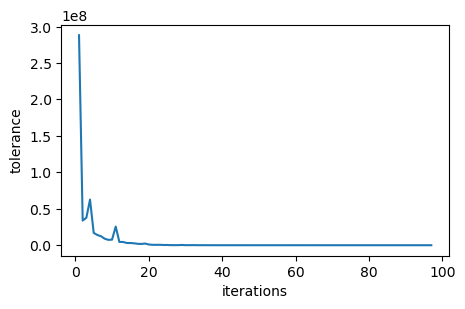

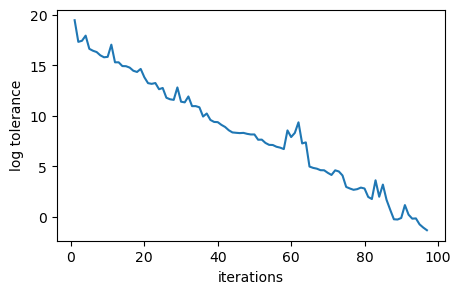

CGM with info:  0
  --> time = 0.04  min |  2.22 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 5.75  min |  345.24 seconds


In [4]:
u_gridded_AS209, v_gridded_AS209, Vis_model_AS209, FrankObj_AS209, GeomObj_AS209, input_frank_AS209 = frank2d_cpu(
                                            'AS209 1mm',
                                            'uvtables/uvtable_AS209_continuum.npz',
                                            {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3 },
                                            1.2*2,
                                            300
                                            )

In [5]:
# Plots.
Plot_AS209 = Plot(FrankObj_AS209, GeomObj_AS209)

In [6]:
u_AS209, v_AS209, Vis_AS209, Weights_AS209 = input_frank_AS209
Rout_AS209 = 3
#Plot_AS209.compare_vis_profile_frank1d(Rout_AS209, u_AS209, v_AS209, Vis_AS209, Weights_AS209)

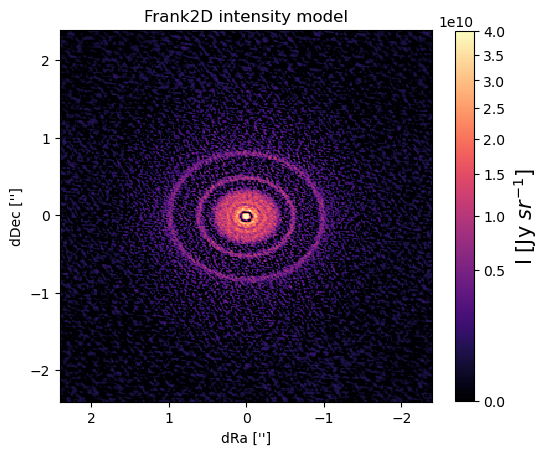

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


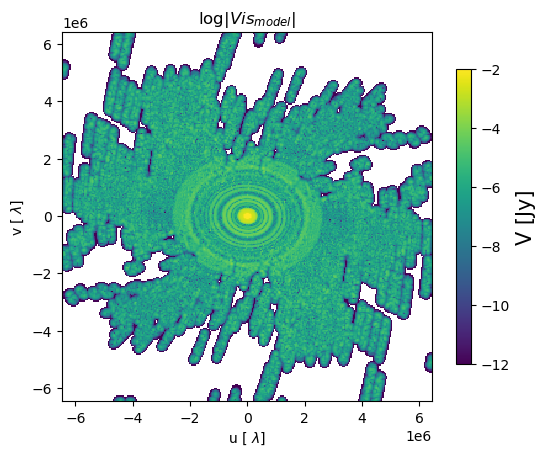

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


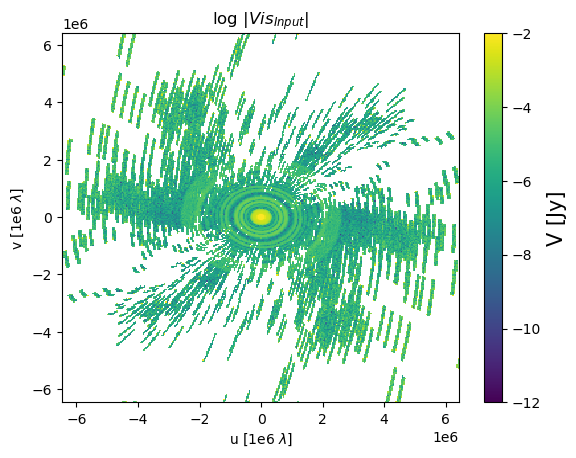

In [7]:
Plot_AS209.intensity_model(vmax = 4e10)
Plot_AS209.visibility_model()
Plot_AS209.visibility_gridded_input()

# HD163006 

Running: HD143006 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.22  min |  13.32 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 2.98  min |  178.64 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.79  min |  47.60 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.12488686114852778
....................... TOLERANCE:  0.12488686114852778
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  124886861.14852777 vs  0.12488686114852778
.... iteration:  1
                        -> actual tol:  14822573.879825262 vs  0.12488686114852778
.... iteration:  2
                        -> actual tol:  6129263.212931977 vs  0.12488686114852778
.... iteration:  3
                        -> actual tol:  3909986.832913086 

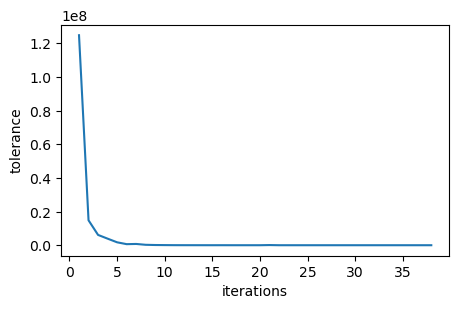

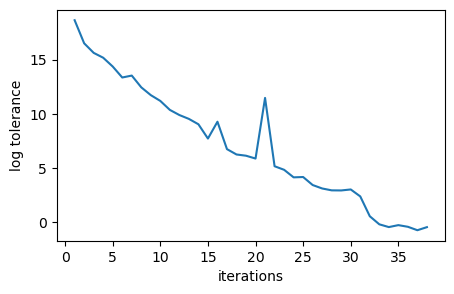

CGM with info:  0
  --> time = 0.01  min |  0.49 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 4.00  min |  240.07 seconds


In [8]:
u_gridded_HD163006, v_gridded_HD163006, Vis_model_HD163006, FrankObj_HD163006, GeomObj_HD163006, input_frank_HD163006 = frank2d_cpu(
                                                'HD143006 1mm',
                                                'uvtables/uvtable_HD143006_continuum.npz', 
                                                {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3 },
                                                0.518*3,
                                                N = 300
                                                )

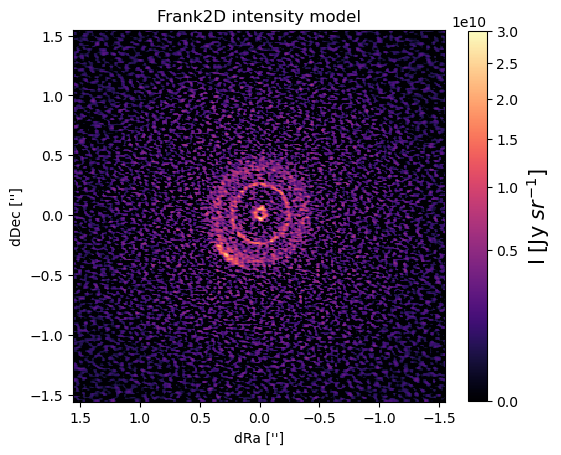

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


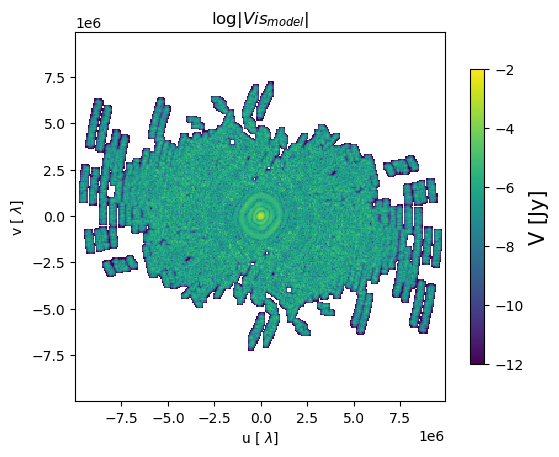

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


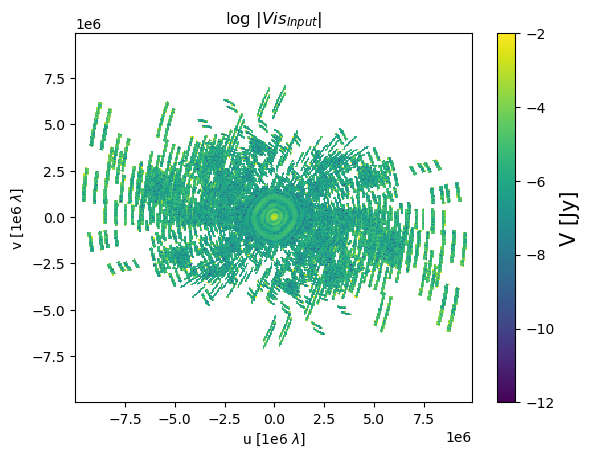

In [9]:
# Plots.
Plot_HD163006 = Plot(FrankObj_HD163006, GeomObj_HD163006)
Plot_HD163006.intensity_model(vmax = 3e10)
Plot_HD163006.visibility_model()
Plot_HD163006.visibility_gridded_input()

# Elias27

Running: Elias27 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.28  min |  16.82 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 7.50  min |  449.84 seconds
---------------------------------
------> Creating sparse system
  --> time = 4.81  min |  288.70 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.05684907757598309
....................... TOLERANCE:  0.05684907757598309
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  56849077.57598309 vs  0.05684907757598309
.... iteration:  1
                        -> actual tol:  11119433.349625174 vs  0.05684907757598309
.... iteration:  2
                        -> actual tol:  5614276.484502957 vs  0.05684907757598309
.... iteration:  3
                        -> actual tol:  13078175.210002512 

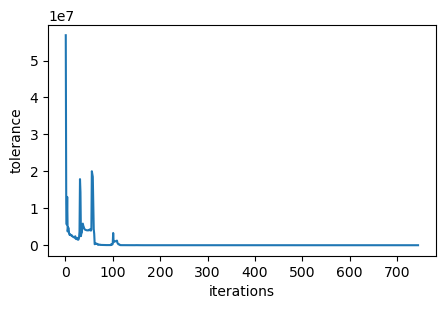

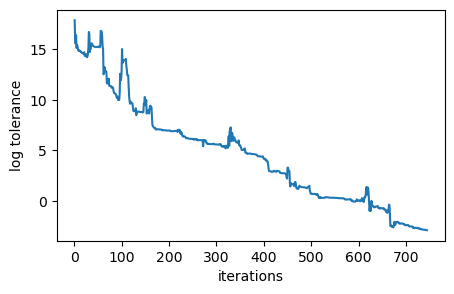

CGM with info:  0
  --> time = 1.06  min |  63.64 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 13.65  min |  819.27 seconds


In [10]:
u_gridded_Elias27, v_gridded_Elias27, Vis_model_Elias27, FrankObj_Elias27, GeomObj_Elias27, input_frank_Elias27 = frank2d_cpu(
                                            'Elias27 1mm',
                                            'uvtables/uvtable_Elias27_continuum.npz',
                                            {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3 },
                                            1.88*2,
                                            N = 300
                                            )

In [11]:
# Plots.
Plot_Elias27 = Plot(FrankObj_Elias27, GeomObj_Elias27)

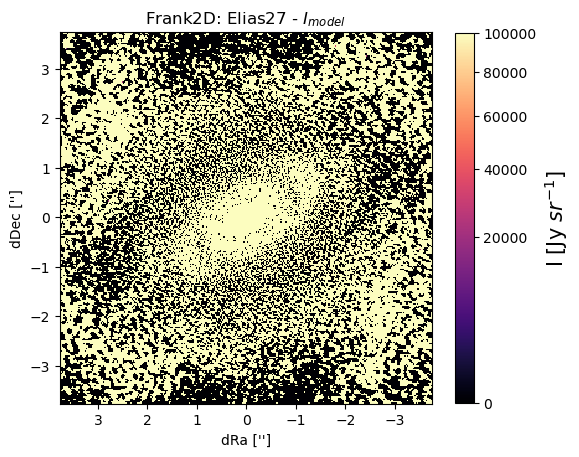

In [12]:
Plot_Elias27.intensity_model(vmax = 1e5, title = r'Frank2D: Elias27 - $I_{model}$')

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


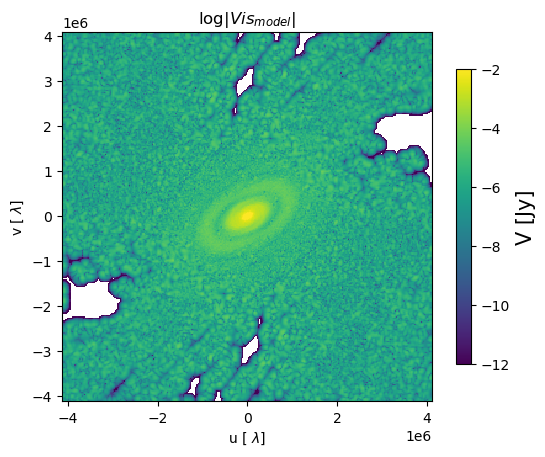

In [13]:
Plot_Elias27.visibility_model()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


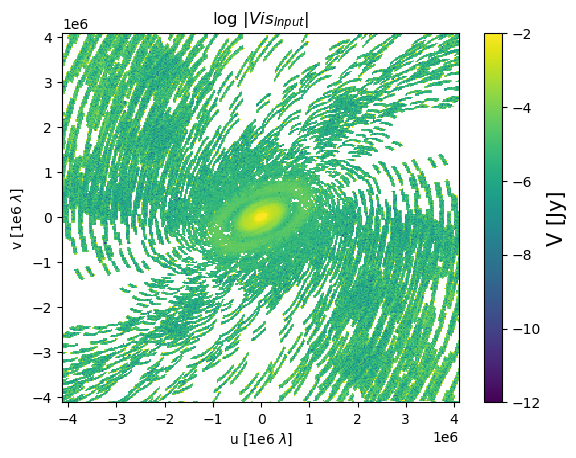

In [14]:
Plot_Elias27.visibility_gridded_input()

In [15]:
Plot_Elias27.get_vis_profile(100)

(array([  29092.66819497,   87278.00458491,  145463.34097485,
         203648.67736479,  261834.01375473,  320019.35014467,
         378204.68653461,  436390.02292455,  494575.3593145 ,
         552760.69570444,  610946.03209438,  669131.36848432,
         727316.70487426,  785502.0412642 ,  843687.37765414,
         901872.71404408,  960058.05043402, 1018243.38682396,
        1076428.7232139 , 1134614.05960384, 1192799.39599378,
        1250984.73238372, 1309170.06877366, 1367355.4051636 ,
        1425540.74155355, 1483726.07794349, 1541911.41433343,
        1600096.75072337, 1658282.08711331, 1716467.42350325,
        1774652.75989319, 1832838.09628313, 1891023.43267307,
        1949208.76906301, 2007394.10545295, 2065579.44184289,
        2123764.77823283, 2181950.11462277, 2240135.45101271,
        2298320.78740265, 2356506.1237926 , 2414691.46018254,
        2472876.79657248, 2531062.13296242, 2589247.46935236,
        2647432.8057423 , 2705618.14213224, 2763803.47852218,
        

# IMLup

Running: IMLup 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.31  min |  18.56 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 8.09  min |  485.24 seconds
---------------------------------
------> Creating sparse system
  --> time = 5.57  min |  334.11 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.1361269242166311
....................... TOLERANCE:  0.1361269242166311
         * maxiter:  40000
.... iteration:  0
                        -> actual tol:  136126924.2166311 vs  0.1361269242166311
.... iteration:  1
                        -> actual tol:  19940296.29974118 vs  0.1361269242166311
.... iteration:  2
                        -> actual tol:  13262500.211354129 vs  0.1361269242166311
.... iteration:  3
                        -> actual tol:  10684432.223992744 vs  0.1

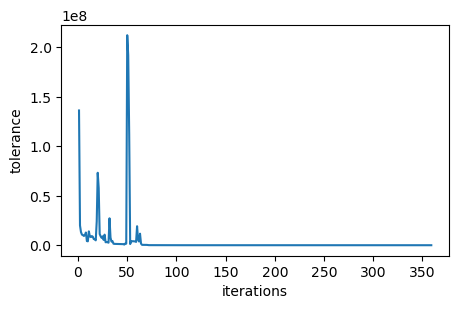

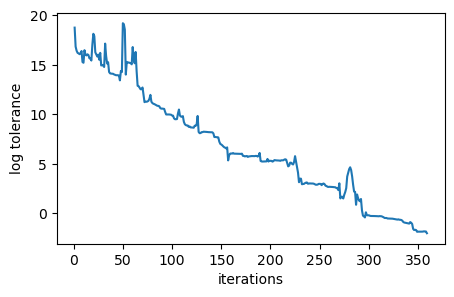

CGM with info:  0
  --> time = 0.48  min |  28.54 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 14.44  min |  866.67 seconds


In [16]:
u_gridded_IMLup, v_gridded_IMLup, Vis_model_IMLup, FrankObj_IMLup, GeomObj_IMLup, input_frank_IMLup =  frank2d_cpu(
                                            'IMLup 1mm',
                                            'uvtables/uvtable_IMLup_continuum.npz',
                                            {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3 },
                                            1.71*2,
                                            N = 300, 
                                            maxiter = 40000
                                            )

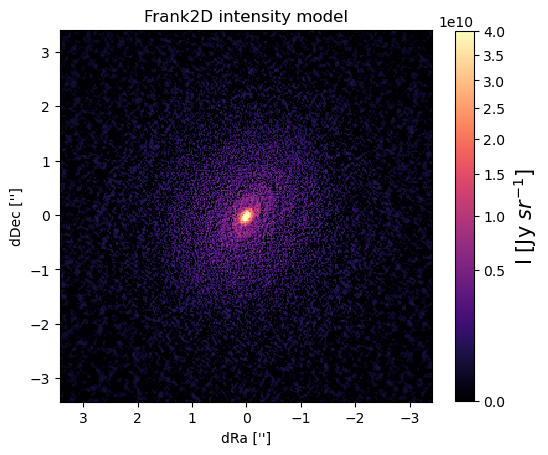

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


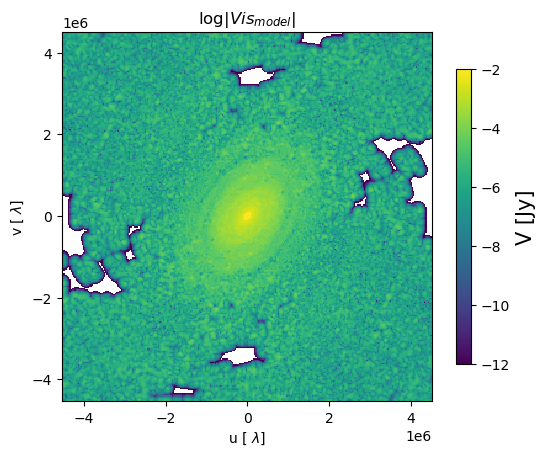

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


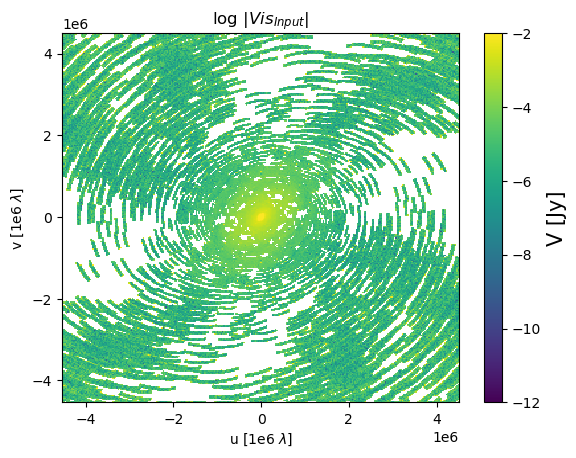

In [17]:
# Plots.
Plot_IMLup = Plot(FrankObj_IMLup, GeomObj_IMLup)
Plot_IMLup.intensity_model()
Plot_IMLup.visibility_model()
Plot_IMLup.visibility_gridded_input()

# Elias24

Running: Elias24 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.16  min |  9.90 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 4.11  min |  246.50 seconds
---------------------------------
------> Creating sparse system
  --> time = 1.49  min |  89.30 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.06400694976529923
....................... TOLERANCE:  0.06400694976529923
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  64006949.76529922 vs  0.06400694976529923
.... iteration:  1
                        -> actual tol:  9358576.708195362 vs  0.06400694976529923
.... iteration:  2
                        -> actual tol:  25015946.398144886 vs  0.06400694976529923
.... iteration:  3
                        -> actual tol:  12818769.524696508 vs

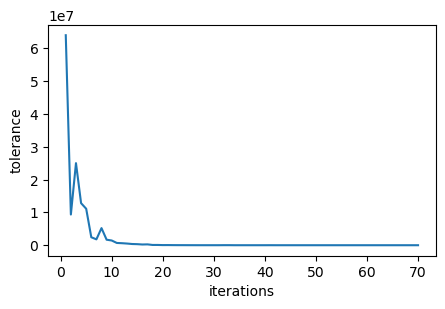

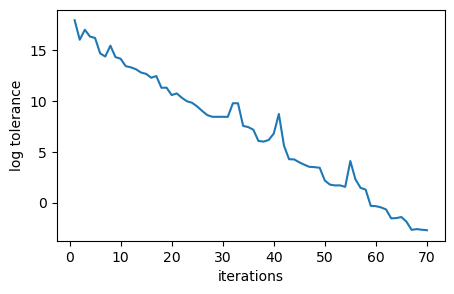

CGM with info:  0
  --> time = 0.02  min |  1.42 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 5.79  min |  347.18 seconds


In [18]:
u_gridded_Elias24, v_gridded_Elias24, Vis_model_Elias24, FrankObj_Elias24, GeomObj_Elias24, input_frank_Elias24 = frank2d_cpu(
                                            'Elias24 1mm',
                                            'uvtables/uvtable_Elias24_continuum.npz',
                                            {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3 },
                                            1.03*2,
                                            300
                                            )

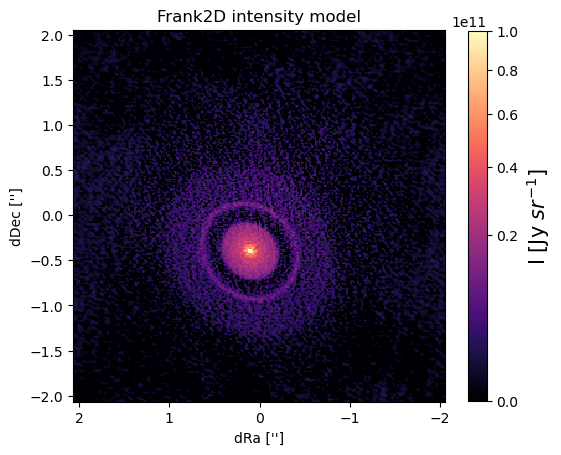

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


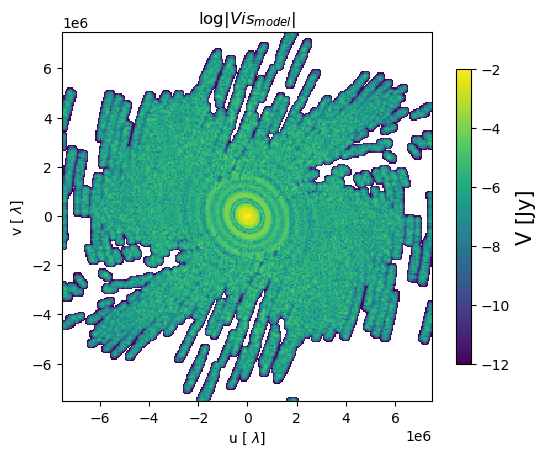

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


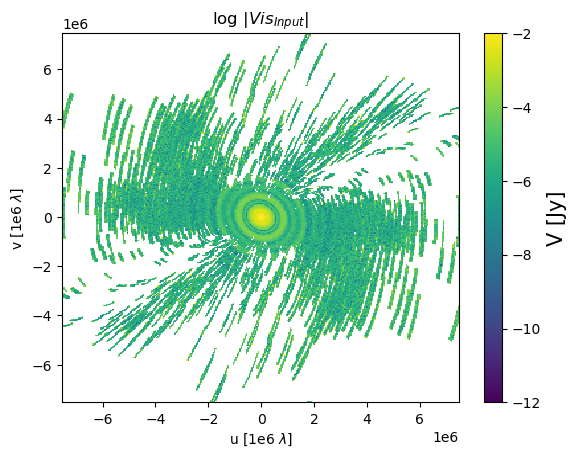

In [19]:
# Plots.
Plot_Elias24 = Plot(FrankObj_Elias24, GeomObj_Elias24)
Plot_Elias24.intensity_model(vmax = 1e11)
Plot_Elias24.visibility_model()
Plot_Elias24.visibility_gridded_input()

# HD163296

Running: HD163296 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.13  min |  7.83 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 3.95  min |  237.19 seconds
---------------------------------
------> Creating sparse system
  --> time = 1.37  min |  82.48 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.8282981234488471
....................... TOLERANCE:  0.8282981234488471
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  828298123.448847 vs  0.8282981234488471
.... iteration:  1
                        -> actual tol:  144424605.39820483 vs  0.8282981234488471
.... iteration:  2
                        -> actual tol:  179138151.59817266 vs  0.8282981234488471
.... iteration:  3
                        -> actual tol:  82653239.71423337 vs  0.8

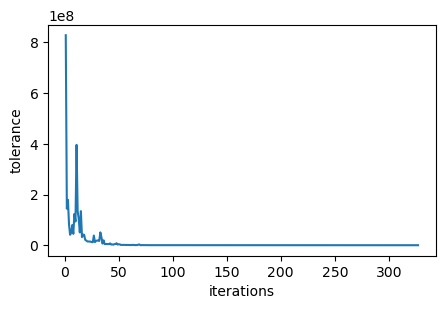

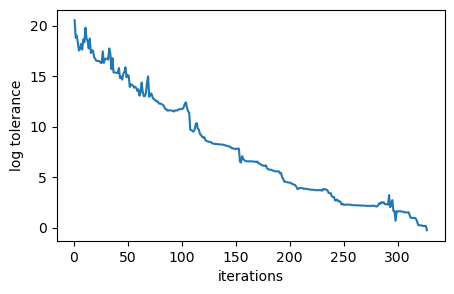

CGM with info:  0
  --> time = 0.19  min |  11.32 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 5.65  min |  338.91 seconds


In [20]:
u_gridded_HD163296, v_gridded_HD163296, Vis_model_HD163296, FrankObj_HD163296, GeomObj_HD163296, input_frank_HD163296 = frank2d_cpu(
                                            'HD163296 1mm',
                                            'uvtables/uvtable_HD163296_continuum.npz',
                                            {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3},
                                            1.7*2,
                                            300
                                            )

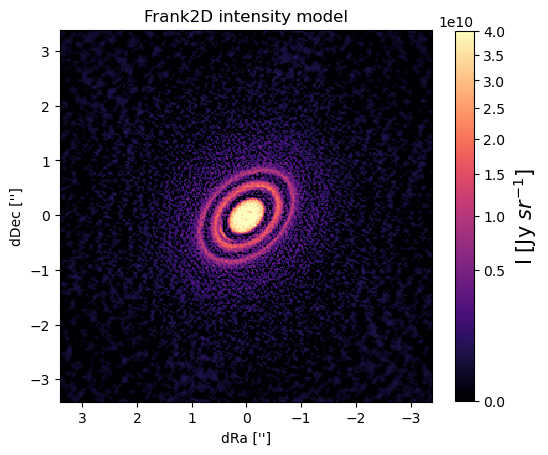

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


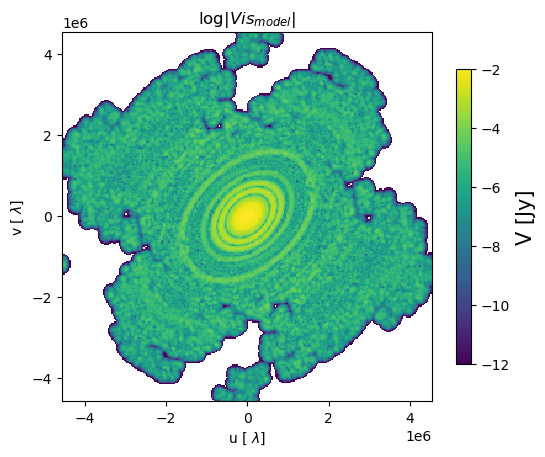

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


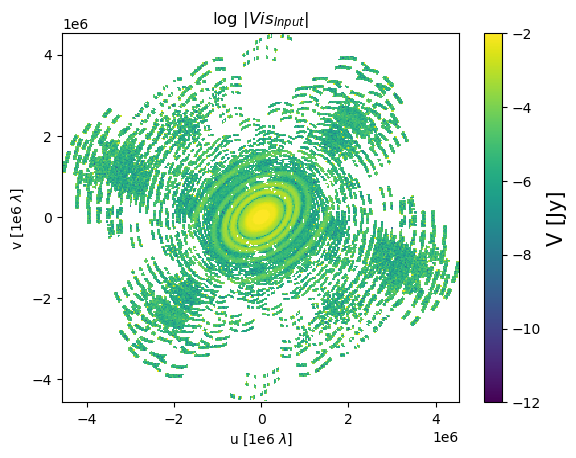

In [21]:
# Plots.
Plot_HD163296 = Plot(FrankObj_HD163296, GeomObj_HD163296)
Plot_HD163296.intensity_model()
Plot_HD163296.visibility_model()
Plot_HD163296.visibility_gridded_input()

# AS205

Running: AS205 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.12  min |  7.08 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 5.58  min |  334.60 seconds
---------------------------------
------> Creating sparse system
  --> time = 2.68  min |  161.01 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.27802796673300223
....................... TOLERANCE:  0.27802796673300223
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  278027966.7330022 vs  0.27802796673300223
.... iteration:  1
                        -> actual tol:  52151150.73361938 vs  0.27802796673300223
.... iteration:  2
                        -> actual tol:  15532907.521400819 vs  0.27802796673300223
.... iteration:  3
                        -> actual tol:  34288678.568767376 vs 

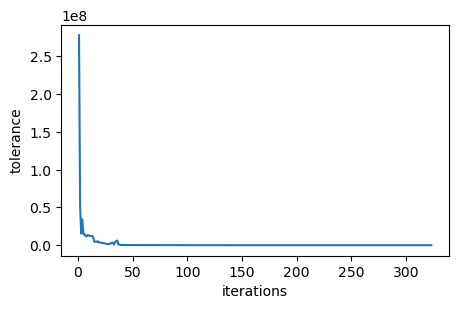

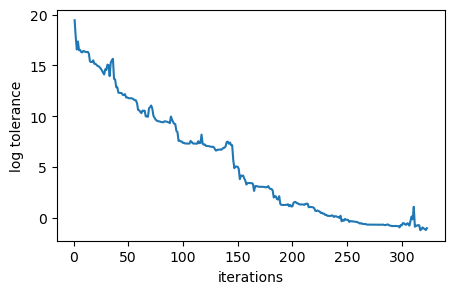

CGM with info:  0
  --> time = 0.22  min |  13.17 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 8.60  min |  515.98 seconds


In [22]:
u_gridded_AS205, v_gridded_AS205, Vis_model_AS205, FrankObj_AS205, GeomObj_AS205, input_frank_AS205 = frank2d_cpu(
                                            'AS205 1mm',
                                            'uvtables/uvtable_AS205_continuum.npz',
                                            {'inc':0, 'pa':0, 'dra':0, 'ddec':0},
                                            1.5*2,
                                            300
                                            )

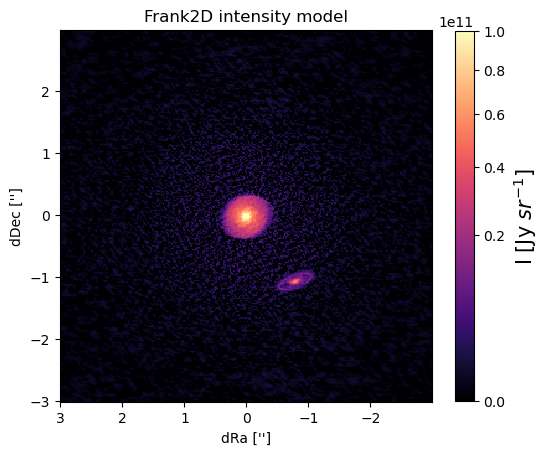

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


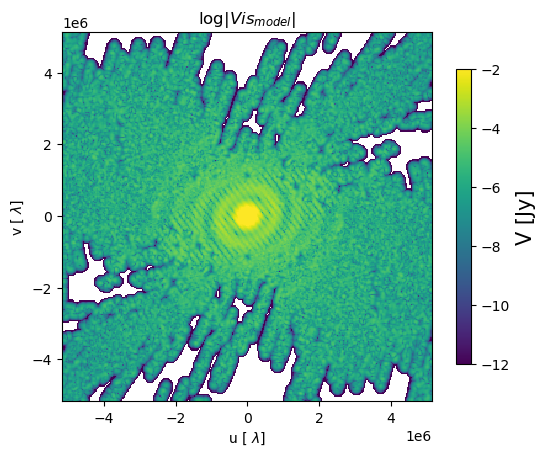

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


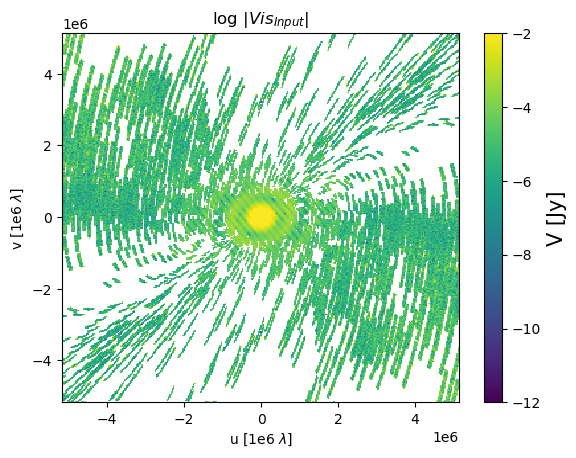

In [23]:
# Plots.
Plot_AS205 = Plot(FrankObj_AS205, GeomObj_AS205)
Plot_AS205.intensity_model(vmax = 1e11)
Plot_AS205.visibility_model()
Plot_AS205.visibility_gridded_input()

# WaOph6

Running: WaOph6 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.24  min |  14.54 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 2.04  min |  122.47 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.38  min |  22.55 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.23960368421759717
....................... TOLERANCE:  0.23960368421759717
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  239603684.21759716 vs  0.23960368421759717
.... iteration:  1
                        -> actual tol:  25989015.34744442 vs  0.23960368421759717
.... iteration:  2
                        -> actual tol:  12410379.074057605 vs  0.23960368421759717
.... iteration:  3
                        -> actual tol:  16628176.785489602 v

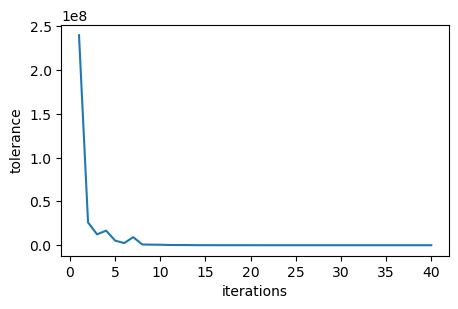

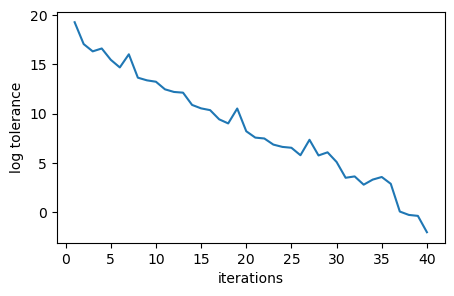

CGM with info:  0
  --> time = 0.01  min |  0.44 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 2.67  min |  160.04 seconds


In [24]:
u_gridded_WaOph6, v_gridded_WaOph6, Vis_model_WaOph6, FrankObj_WaOph6, GeomObj_WaOph6, input_frank_WaOph6 = frank2d_cpu(
                                            'WaOph6 1mm',
                                            'uvtables/uvtable_WaOph6_continuum.npz',
                                            {'inc': 47.3 , 'pa':174.2, 'dra':-244e-3, 'ddec':-361e-3},
                                            0.859*2,
                                            300
                                            )

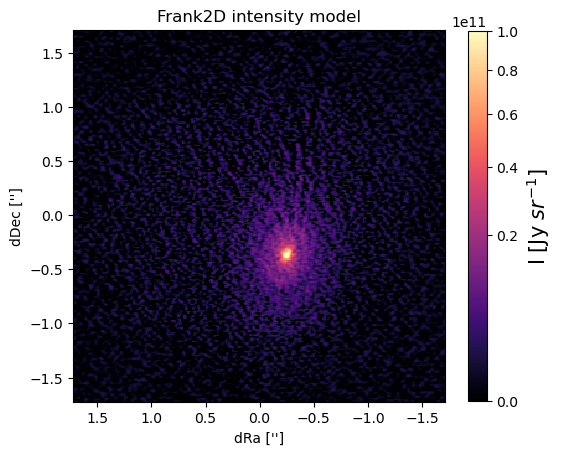

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


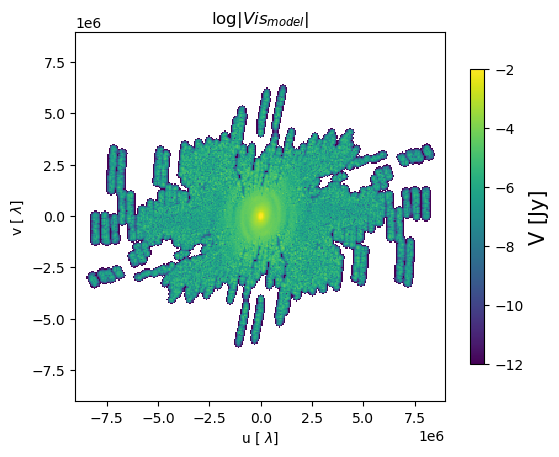

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


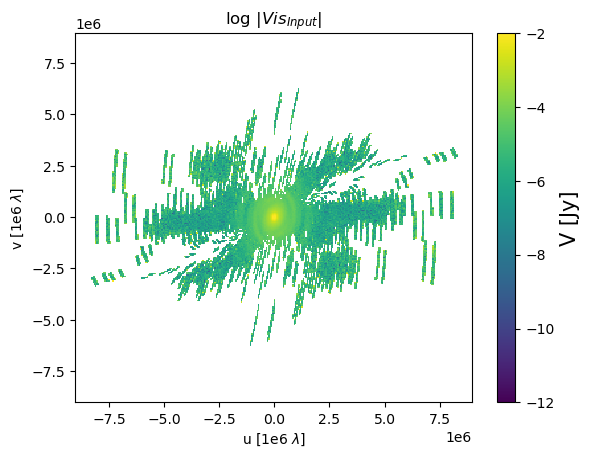

In [25]:
# Plots.
Plot_WaOph6 = Plot(FrankObj_WaOph6, GeomObj_WaOph6)
Plot_WaOph6.intensity_model(vmax = 1e11)
Plot_WaOph6.visibility_model()
Plot_WaOph6.visibility_gridded_input()

# HTLup

Running: HTLup 1mm .... frank2d model with 300x300 points
Enforcing Hermitian symmetry...
  --> time = 0.19  min |  11.53 seconds
Setting gridded data...
RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
------> Creating linear operators
  --> time = 3.74  min |  224.41 seconds
---------------------------------
------> Creating sparse system
  --> time = 1.25  min |  75.27 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.12405082120077508
....................... TOLERANCE:  0.12405082120077508
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  124050821.20077507 vs  0.12405082120077508
.... iteration:  1
                        -> actual tol:  7240234.276015635 vs  0.12405082120077508
.... iteration:  2
                        -> actual tol:  4981994.645236456 vs  0.12405082120077508
.... iteration:  3
                        -> actual tol:  2429367.560143825 vs  

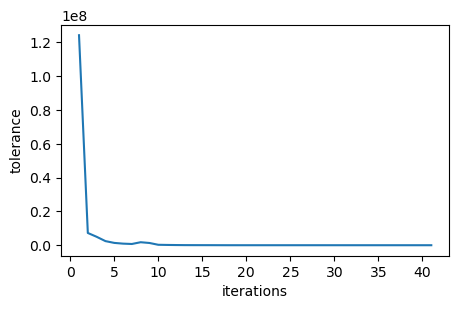

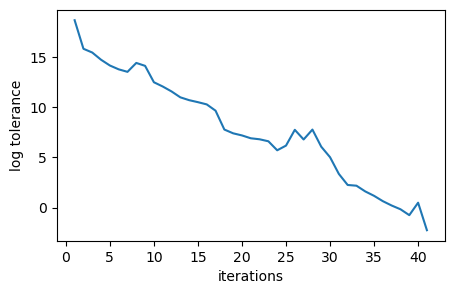

CGM with info:  0
  --> time = 0.01  min |  0.73 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 5.20  min |  311.97 seconds


In [26]:
u_gridded_HTLup, v_gridded_HTLup, Vis_model_HTLup, FrankObj_HTLup, GeomObj_HTLup, input_frank_HTLup = frank2d_cpu(
                                            'HTLup 1mm',
                                            'uvtables/uvtable_HTLup_continuum.npz',
                                            {'inc': 0 , 'pa':0, 'dra':0, 'ddec':0},
                                            0.859*2,
                                            300
                                            )

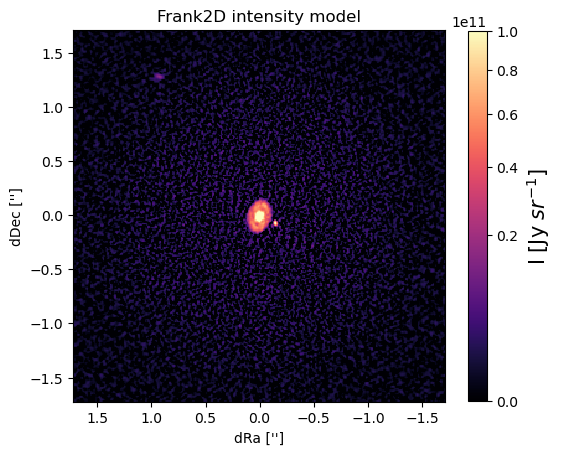

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:102: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


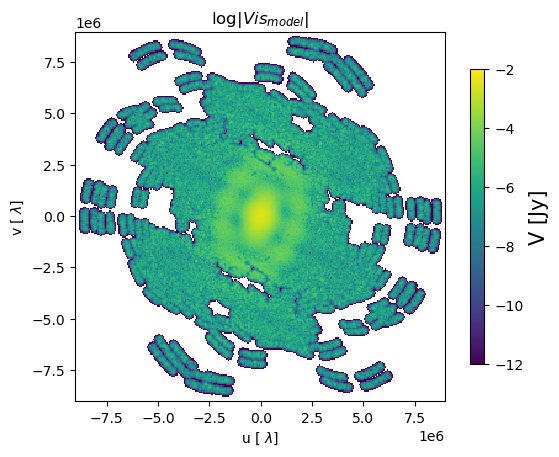

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_83466/1510174401.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


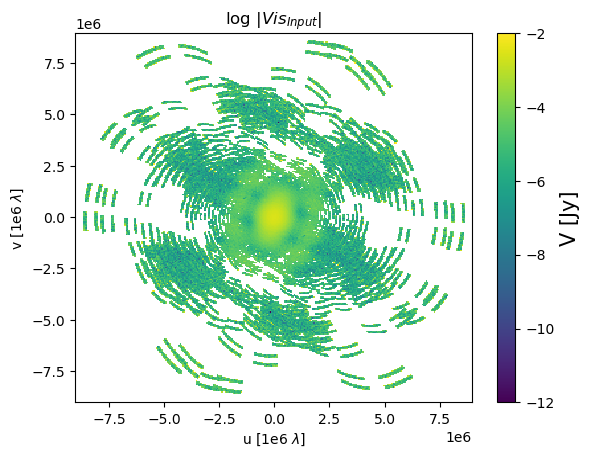

In [28]:
# Plots.
Plot_HTLup = Plot(FrankObj_HTLup, GeomObj_HTLup)
Plot_HTLup.intensity_model(vmax = 1e11)
Plot_HTLup.visibility_model()
Plot_HTLup.visibility_gridded_input()